In [33]:
import glob
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

from pathlib import Path
from sklearn.ensemble import IsolationForest


In [18]:
# --- 1. Model ---
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model.eval()

Using cache found in /home/pgliwny/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

In [44]:
def denormalize(tensor):
    """Odwraca normalizację ImageNet"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# ---  Ekstrakcja embeddingów ---
def get_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        emb = model(x)  # shape: (1, 384)
    return emb.squeeze().numpy()

def show_img(img_path):
    img_orig = Image.open(img_path).convert("RGB")
    plt.figure()
    plt.imshow(img_orig)
    plt.show()

In [45]:
transform = T.Compose([
    T.Resize((518, 518)),  # wielokrotność 14
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [29]:
image_paths = glob.glob("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/*.jpg")
print(len(image_paths))
for p in image_paths[:5]:
    print(p)

141
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251207_081431M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251207_083431M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251218_085254M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251110_083000M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251207_085431M.jpg


In [30]:
embeddings = np.array([get_embedding(p) for p in image_paths[:]])

In [31]:
# Normalizacja (ważne!)
scaler = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)  # (N, 384)

# PCA → 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_scaled)

print(f"Wyjaśniona wariancja: {pca.explained_variance_ratio_.sum():.1%}")

Wyjaśniona wariancja: 46.3%


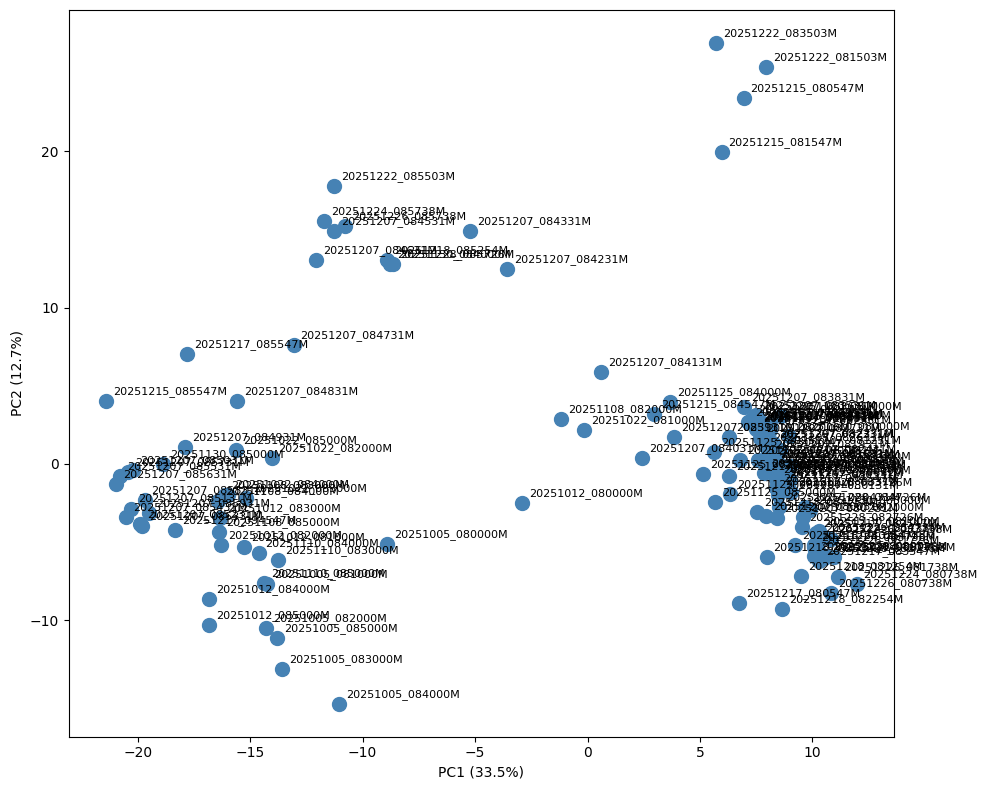

In [32]:
# Wykres
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=100, c='steelblue')

# Etykiety = nazwa pliku
for i, path in enumerate(image_paths[:]):
    label = Path(path).stem[-16:]  # np. "315_111700"
    ax.annotate(label, (emb_2d[i, 0], emb_2d[i, 1]),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()

In [57]:
# Najlepiej na oryginalnych embeddingach, nie na 2D!
iso = IsolationForest(contamination=0.05, random_state=42)
# contamination = oczekiwany % outlierów (tutaj 10% = ~14 zdjęć)
outlier_labels = iso.fit_predict(emb_scaled)  # -1 = outlier, 1 = normal

# Anomaly score (im niższy tym bardziej outlier)
scores = iso.score_samples(emb_scaled)

outlier_idx = np.where(outlier_labels == -1)[0]
print(f"Znalezione outliery: {len(outlier_idx)}")
for i in outlier_idx:
    print(f"  [{i}] {image_paths[i]}  score={scores[i]:.3f}")

Znalezione outliery: 7
  [20] /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251217_094547M.jpg  score=-0.533
  [33] /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251215_081547M.jpg  score=-0.667
  [78] /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251222_083503M.jpg  score=-0.647
  [86] /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251215_080547M.jpg  score=-0.667
  [98] /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251222_085503M.jpg  score=-0.574
  [116] /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251222_081503M.jpg  score=-0.615
  [138] /home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251215_085547M.jpg  score=-0.520


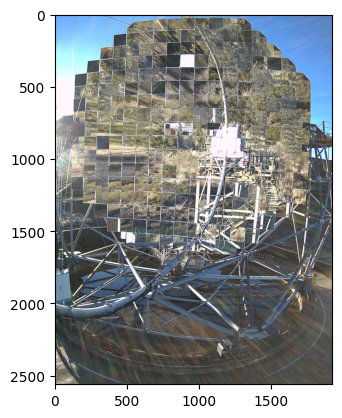

In [64]:
show_img(image_paths[138])

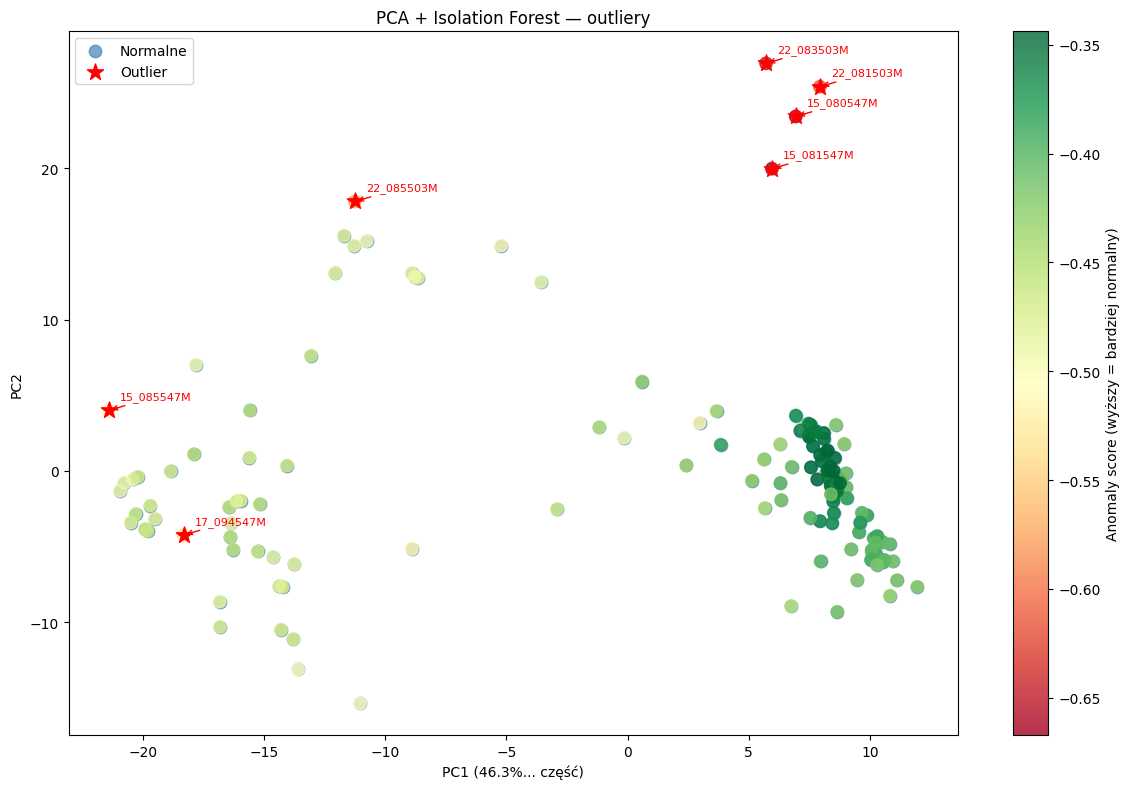

In [67]:
fig, ax = plt.subplots(figsize=(12, 8))

# Normalne punkty
normal_mask = outlier_labels == 1
ax.scatter(emb_2d[normal_mask, 0], emb_2d[normal_mask, 1],
           c='steelblue', s=80, alpha=0.7, label='Normalne')

# Outliery
outlier_mask = outlier_labels == -1
ax.scatter(emb_2d[outlier_mask, 0], emb_2d[outlier_mask, 1],
           c='red', s=150, marker='*', zorder=5, label='Outlier')

# Kolor = anomaly score (gradient)
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=scores, cmap='RdYlGn', s=80, alpha=0.8)
plt.colorbar(sc, label='Anomaly score (wyższy = bardziej normalny)')

# Etykiety dla outlierów
for i in outlier_idx:
    label = Path(image_paths[i]).stem[-10:]
    ax.annotate(label, (emb_2d[i, 0], emb_2d[i, 1]),
                fontsize=8, color='red',
                xytext=(8, 8), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax.set_xlabel(f'PC1 (46.3%... część)')
ax.set_ylabel('PC2')
ax.legend()
ax.set_title('PCA + Isolation Forest — outliery')
plt.tight_layout()
plt.savefig('outliers_pca.png', dpi=150)

# Visualization

In [8]:
path = image_paths[5]
img_orig = Image.open(path).convert("RGB")
tensor   = transform(img_orig)          # po transformacji: (3, 518, 518)
img_back = denormalize(tensor)          # odwróć normalizację
img_np   = img_back.permute(1, 2, 0).numpy()  # (518, 518, 3)

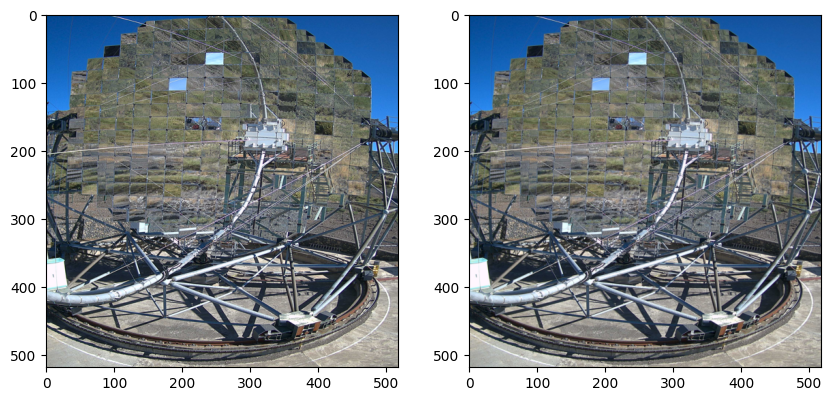

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[0].imshow(img_orig.resize((518, 518)))
ax[1].imshow(img_np)
            

In [66]:
np.array(img_orig).shape

(2560, 1920, 3)